In [42]:
import itertools

import sympy as sy
import numpy as np

In [43]:
import fitz

In [44]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

Tamanho dos vetores

In [45]:
from utils import plot_pdf

In [46]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This example will not work for different vector sizes.

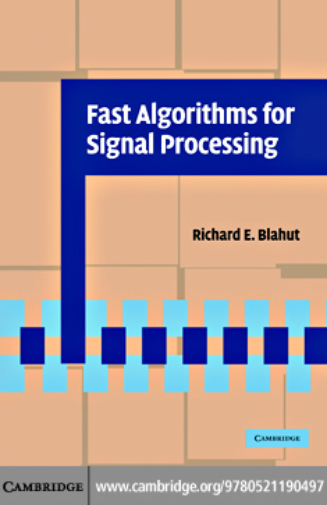

In [47]:
plot_pdf(doc[0], dpi=100)

In [48]:
d_num = 3
g_num = 2

Vetor de exemplo

In [49]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))

Grau do polinômio

In [50]:
d_degree = d_num - 1
g_degree = g_num - 1

In [51]:
x = sy.symbols("x")

In [52]:
# sy.factor(x**4-1)

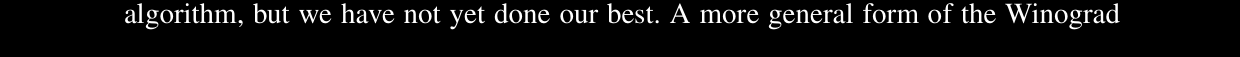

In [53]:
plot_pdf(doc[177], [.91, .94])

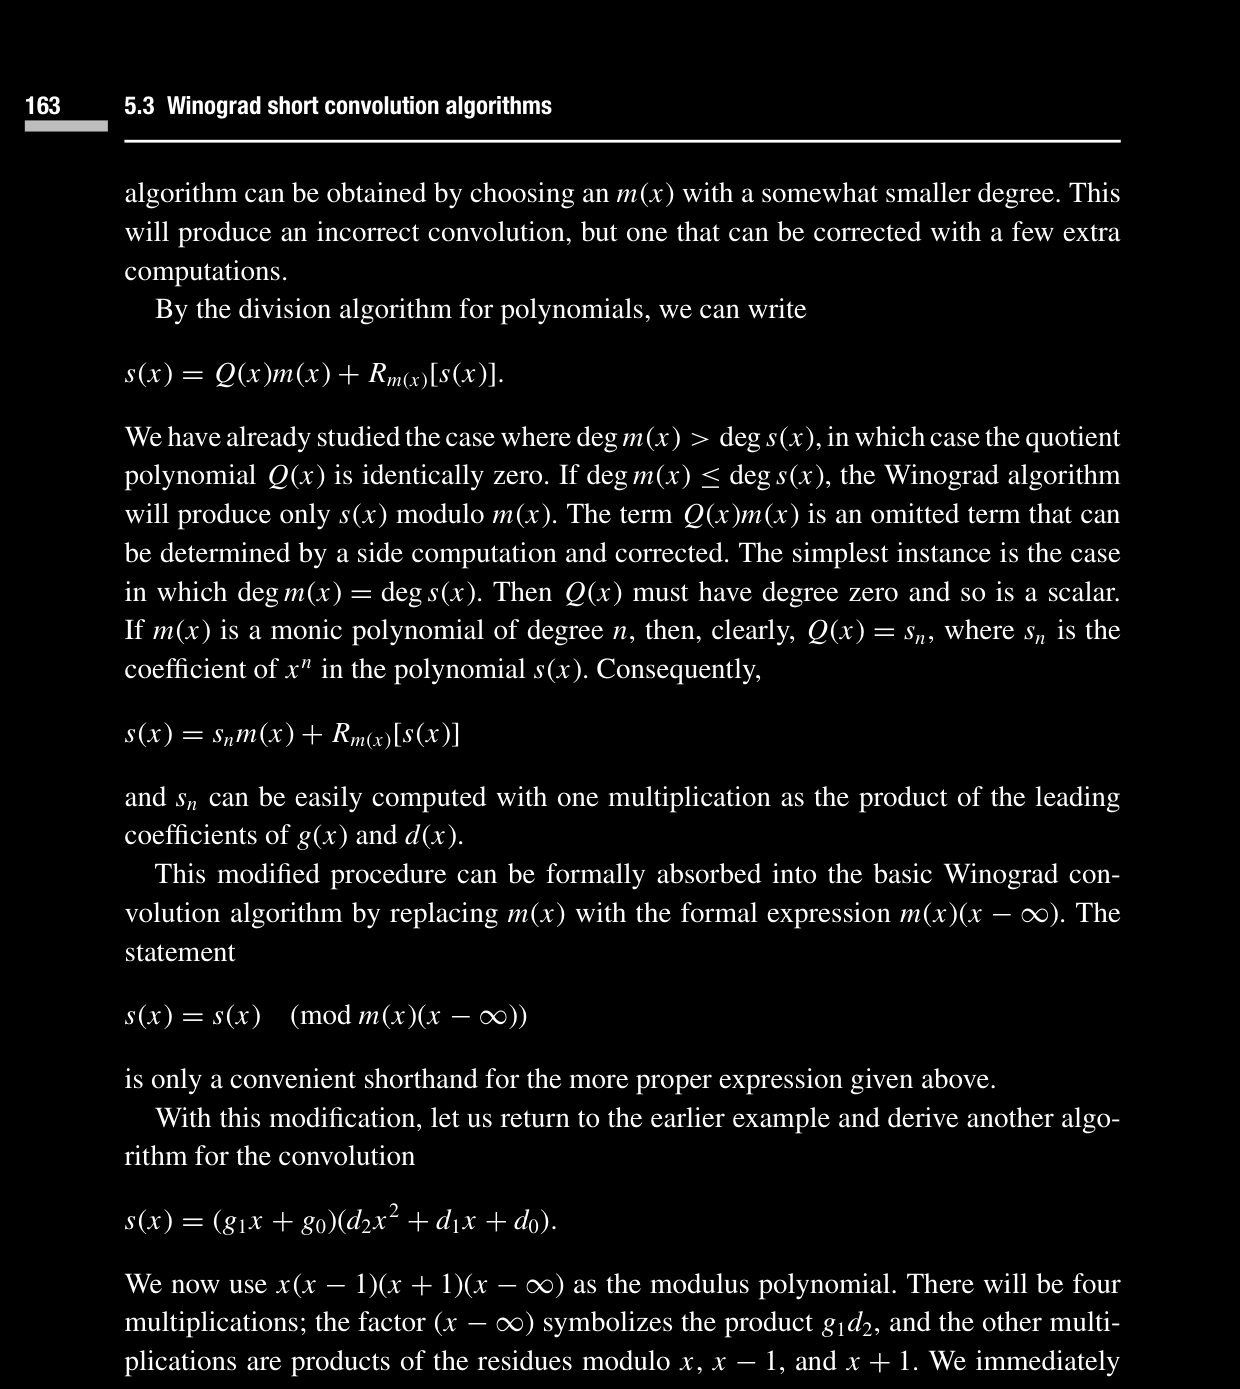

In [54]:
plot_pdf(doc[178], [0, .731])

Total of residues

In [55]:
d_degree + g_degree

In [56]:
# mk0 = [x + i*r for r in range(1, d_degree + g_degree - 1) for i in [-1, 1]]
# mk = sy.Matrix(([x] + mk0)[:d_degree + g_degree])

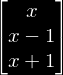

In [57]:
mk = sy.Matrix([x, x - 1, x + 1])
mk

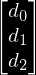

In [58]:
di = sy.Matrix(sy.symbols(" ".join(f"d{i}"for i in range(d_num))))
di

In [59]:
gi = sy.Matrix(sy.symbols(" ".join(f"g{i}"for i in range(g_num))))
gi

In [60]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

In [61]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

In [62]:
sx = gx*dx
sx

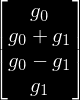

In [63]:
gk_ = [sy.rem(gx, q, domain ='ZZ') for q in mk]
gk = sy.Matrix(gk_ + [gx.args[-1].args[0]])
gk

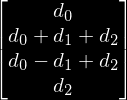

In [64]:
dk_ = [sy.rem(dx, q, domain ='ZZ') for q in mk]
dk = sy.Matrix(dk_ + [dx.args[-1].args[0]])
dk

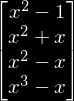

In [65]:
mmk_ = [sy.expand(np.prod(d)) for d in itertools.combinations(reversed(mk), len(mk)-1)]
mmk = sy.Matrix(mmk_ + [sy.expand(np.prod(mk))])
mmk

Pegando quociente e resto, agora tem q colocar no formato nm+NM=1

In [66]:
mx_div = [sy.div(dv, ds, domain ='ZZ') for dv, ds in zip(mmk, mk)]
mx_div

Multiplicar o resto pela matriz G depois
o sinal negativo vai pra matriz G e não pra C

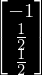

In [67]:
nnk = sy.Matrix([1/z[1] for z in mx_div])
nnk

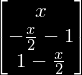

In [68]:
nk = sy.Matrix([q[0]*r*(-1) for q, r in zip(mx_div, nnk)])
nk

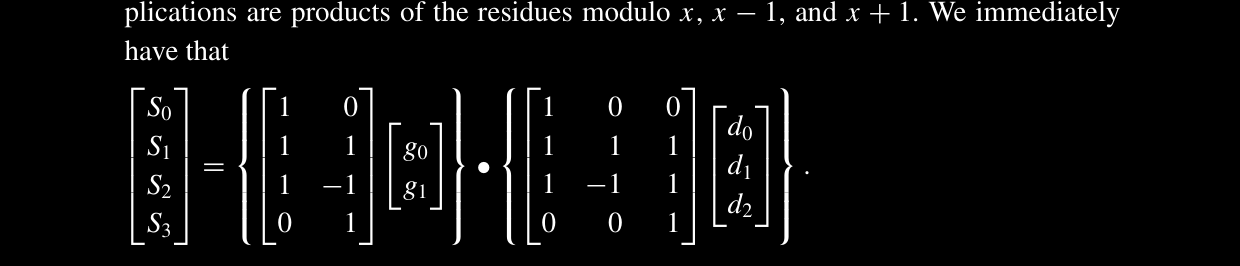

In [69]:
plot_pdf(doc[178], [.71, .85])

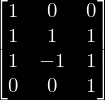

In [70]:
a_mtx = sy.Matrix([[d.coeff(c, 1) for c in di] for d in dk])
a_mtx

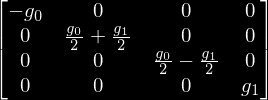

In [71]:
bg_mtx = sy.diag(*([g*r for g, r in zip(gk.flat(), nnk.flat()+[1])]))
bg_mtx

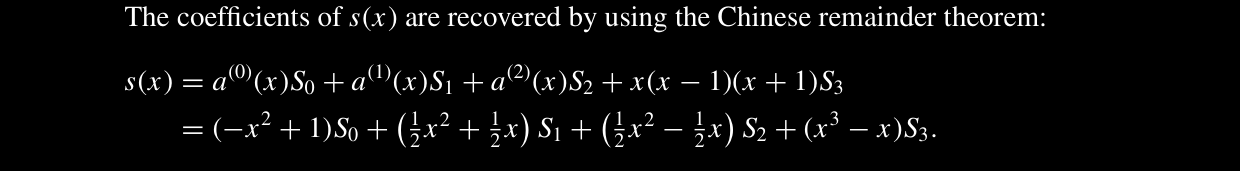

In [72]:
plot_pdf(doc[178], [.85, .94])

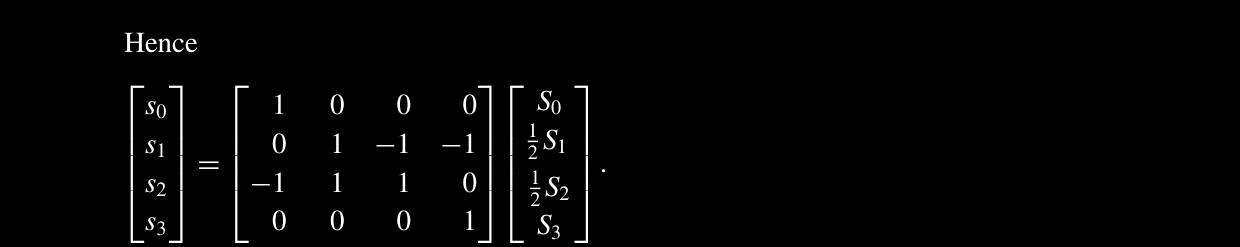

In [73]:
plot_pdf(doc[179], [.25, .38])

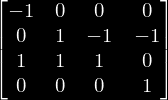

In [74]:
c_mtx = sy.Matrix([[d.coeff(x, c) for d in mmk] for c in range(len(np.prod(mk).as_poly().all_coeffs()))])
c_mtx

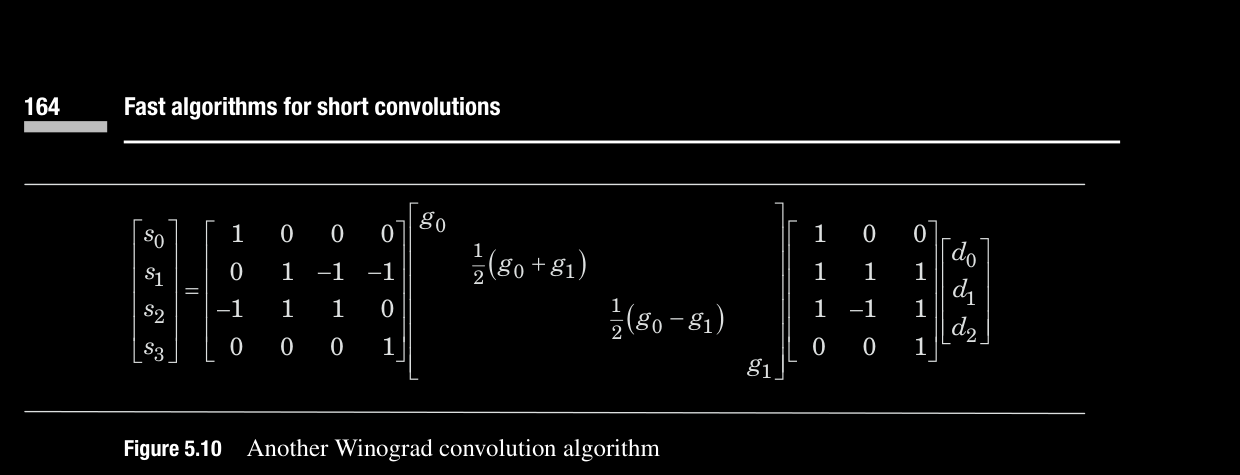

In [75]:
plot_pdf(doc[179], [0, .25])

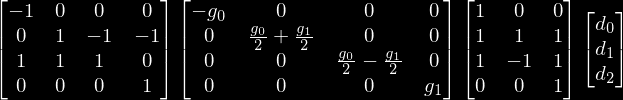

In [76]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di))
s

In [77]:
subs = {k: v for k, v in zip(di.flat()+gi.flat(), d_values + g_values)}
subs

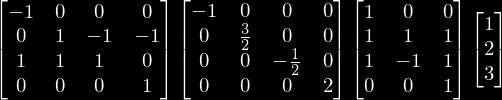

In [78]:
si = s.subs(subs)
si

In [79]:
sy.expand(sx)

Let's compare the output polynomial matrix from direct and winograd method

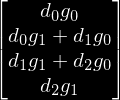

In [80]:
sy.Matrix(np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

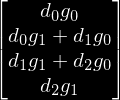

In [81]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di), evaluate=True)
se

Comparing numerical outputs from direct and winograd method

In [82]:
sy.Matrix(np.convolve(d_values, g_values))

In [83]:
se.subs(subs)